# Introduction 
This notebook shows exploratory data analysis, modeling and evaluating tasks, performed on the churn customers [dataset](https://www.kaggle.com/datasets/mnassrib/telecom-churn-datasets) from a telecom company.<br>
Objective: Predict which customer will churn, given a user's features (phone plan, call usage, etc).

The notebook is divided into the following parts:
> 1. Exploratory data analysis
> 2. Data preprocessing
> 3. Modeling and evaluations
> 4. Finding cost-optimal threshold

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix, log_loss, precision_recall_curve, auc
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

In [4]:
# Load datasets
df_test = pd.read_csv(
    "/Users/nguyend.anh/Documents/Data analytics learning/Datasets/[Project] Churn prediction/churn-bigml-20.csv")
df_train = pd.read_csv(
    "/Users/nguyend.anh/Documents/Data analytics learning/Datasets/[Project] Churn prediction/churn-bigml-80.csv")

display(df_train.head(5))
display(df_test.head(5))

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,LA,117,408,No,No,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,False
1,IN,65,415,No,No,0,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4,True
2,NY,161,415,No,No,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,True
3,SC,111,415,No,No,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,False
4,HI,49,510,No,No,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1,False


# 1. Exploratory data analysis

In [5]:
# Clean data
datasets = [df_train, df_test]
# Standardize column names
df_train.columns = (df_train.columns
                    .str.lower()
                    .str.strip()
                    .str.replace(" ", "_")
                    )
df_test.columns = (df_test.columns
                   .str.lower()
                   .str.strip()
                   .str.replace(" ", "_")
                   )

# Convert string, bool column to 0s and 1s
for df in datasets:
    df["international_plan"] = df["international_plan"].map(
        {"Yes": 1, "No": 0})
    df["voice_mail_plan"] = df["voice_mail_plan"].map({"Yes": 1, "No": 0})
    df["churn"] = df["churn"].map({True: 1, False: 0})

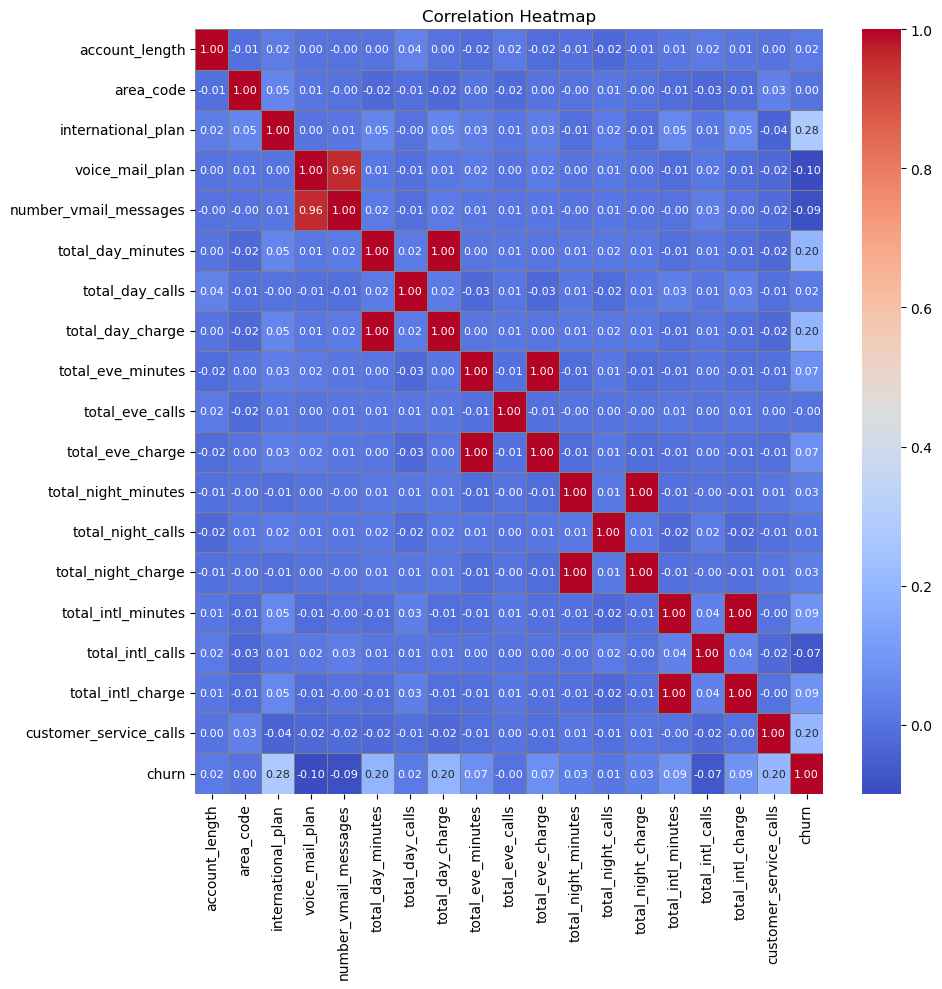

In [6]:
# Draw heatmap to detect colinear features
df_to_heatmap = df_train.drop("state", axis=1).copy()
corr = df_to_heatmap.corr(numeric_only=True)
plt.figure(figsize=(10, 10))
sns.heatmap(corr, annot=True, fmt='.2f',
            cmap="coolwarm", annot_kws={'size': 8}, linewidths=0.5,
            linecolor='gray')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [7]:
# Extract pairs with near perfect colinearity:
upper_mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

row_idx, col_idx = np.where((corr > 0.95) & upper_mask)  # Correlation
zero_pairs = [(corr.index[i], corr.columns[j])
              for i, j in zip(row_idx, col_idx)
              if i != j]
display(zero_pairs)

# I will remove half of these features as they have near perfect correlation, thus can be used alternatively.
col_to_remove = ['voice_mail_plan', 'total_day_charge',
                 'total_eve_charge', 'total_night_charge', 'total_intl_charge']

for df in datasets:
    df.drop(col_to_remove, axis=1, errors="ignore", inplace=True)
    display(df)

[('voice_mail_plan', 'number_vmail_messages'),
 ('total_day_minutes', 'total_day_charge'),
 ('total_eve_minutes', 'total_eve_charge'),
 ('total_night_minutes', 'total_night_charge'),
 ('total_intl_minutes', 'total_intl_charge')]

,state,account_length,area_code,international_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_eve_minutes,total_eve_calls,total_night_minutes,total_night_calls,total_intl_minutes,total_intl_calls,customer_service_calls,churn
0,KS,128,415,0,25,265.1,110,197.4,99,244.7,91,10.0,3,1,0
1,OH,107,415,0,26,161.6,123,195.5,103,254.4,103,13.7,3,1,0
2,NJ,137,415,0,0,243.4,114,121.2,110,162.6,104,12.2,5,0,0
3,OH,84,408,1,0,299.4,71,61.9,88,196.9,89,6.6,7,2,0
4,OK,75,415,1,0,166.7,113,148.3,122,186.9,121,10.1,3,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2661,SC,79,415,0,0,134.7,98,189.7,68,221.4,128,11.8,5,2,0
2662,AZ,192,415,0,36,156.2,77,215.5,126,279.1,83,9.9,6,2,0
2663,WV,68,415,0,0,231.1,57,153.4,55,191.3,123,9.6,4,3,0
2664,RI,28,510,0,0,180.8,109,288.8,58,191.9,91,14.1,6,2,0


,state,account_length,area_code,international_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_eve_minutes,total_eve_calls,total_night_minutes,total_night_calls,total_intl_minutes,total_intl_calls,customer_service_calls,churn
0,LA,117,408,0,0,184.5,97,351.6,80,215.8,90,8.7,4,1,0
1,IN,65,415,0,0,129.1,137,228.5,83,208.8,111,12.7,6,4,1
2,NY,161,415,0,0,332.9,67,317.8,97,160.6,128,5.4,9,4,1
3,SC,111,415,0,0,110.4,103,137.3,102,189.6,105,7.7,6,2,0
4,HI,49,510,0,0,119.3,117,215.1,109,178.7,90,11.1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
662,WI,114,415,0,26,137.1,88,155.7,125,247.6,94,11.5,7,2,0
663,AL,106,408,0,29,83.6,131,203.9,131,229.5,73,8.1,3,1,0
664,VT,60,415,0,0,193.9,118,85.0,110,210.1,134,13.2,8,3,0
665,WV,159,415,0,0,169.8,114,197.7,105,193.7,82,11.6,4,1,0


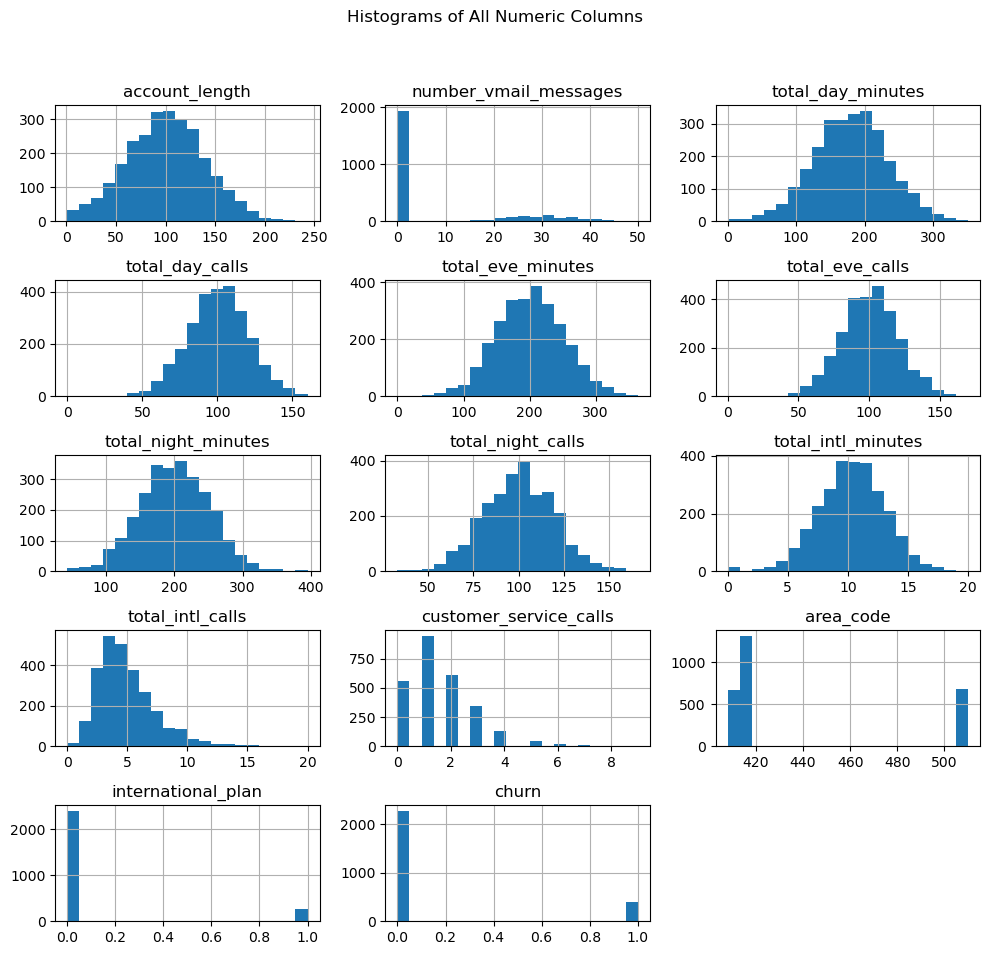

In [8]:
# Let's look at the distributions of data
nu_cols = ['account_length',
           'number_vmail_messages', 'total_day_minutes',
           'total_day_calls', 'total_eve_minutes',
           'total_eve_calls', 'total_night_minutes',
           'total_night_calls', 'total_intl_minutes',
           'total_intl_calls', 'customer_service_calls'
           ]

cate_cols = ["state", "area_code", "international_plan"]
target = ["churn"]

df_train[nu_cols + cate_cols +
         target].hist(figsize=(10, 10), bins=20, layout=(5, 3))
plt.suptitle('Histograms of All Numeric Columns')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Churn is an imbalanced column, with number of negatives dominate number of positives.
# Almost all numerical features are close to normally distributed.
# Except for number_vmail_messages, most customers don't use this service, but if they use it, they usually send/receive around 20-40 messages.

# 2. Preprocessing

In [9]:
# Scale numeric columns
scaler = StandardScaler()
df_train[nu_cols] = scaler.fit_transform(df_train[nu_cols])
df_test[nu_cols] = scaler.transform(df_test[nu_cols])

# Encode categorical columns. Using one-hot encoding as the columns are nominal, they have no natural order.
# This columns is already encoded
cate_drop_col = ["international_plan"]
cate_cols = [col for col in cate_cols if col not in cate_drop_col]
encoder = OneHotEncoder(sparse_output=False,
                        drop='first', handle_unknown='ignore')
train_col_encoded = encoder.fit_transform(df_train[cate_cols])
test_col_encoded = encoder.transform(df_test[cate_cols])

feature_names = encoder.get_feature_names_out(cate_cols)

df_train[feature_names] = train_col_encoded
df_train = df_train.drop(cate_cols, axis=1)

df_test[feature_names] = test_col_encoded
df_test = df_test.drop(cate_cols, axis=1)

# 3. Modeling and evaluations

In [ ]:
# Define X_train, y_train, X_test, y_test arrays
X_train = df_train.loc[:, df_train.columns != target[0]]
y_train = df_train[target]

X_test = df_test.loc[:, df_test.columns != target[0]]
y_test = df_test[target]

y_test.mean() # Test set churn rate for later PR-AUC interpretation

churn    0.142429
dtype: float64

In [28]:
# Logistic regression
# Set class_weight to balanced so the model penalty the misclassification of minority class more.
lr_model = LogisticRegression(
    max_iter=1000, random_state=42, class_weight="balanced")
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict_proba(X_test)[:, 1]

# Produce metrics
auc_val = roc_auc_score(y_test, y_pred_lr)
log_loss_val = log_loss(y_test, y_pred_lr)
precision_lr, recall_lr, thresholds_lr = precision_recall_curve(
    y_test, y_pred_lr)
pr_auc_lr = auc(recall_lr, precision_lr)

display(f"Test set PR-AUC: {pr_auc_lr:.2f}")
display(f"Test set log-loss: {log_loss_val:.2f}")

/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


'Test set PR-AUC: 0.42'

'Test set log-loss: 0.52'

In [26]:
# K-nearest neighbor
knn = KNeighborsClassifier(weights="uniform")
param_grid = {"n_neighbors": range(1, 100)}

grid = GridSearchCV(knn, param_grid, cv=5, scoring="average_precision")
grid.fit(X_train, y_train.values.ravel())
best_k = grid.best_params_["n_neighbors"]
y_proba_knn = grid.predict_proba(X_test)[:, 1]

# Produce metrics
knn_logloss = log_loss(y_test, y_proba_knn)
precision_knn, recall_knn, thresholds_knn = precision_recall_curve(
    y_test, y_proba_knn)
pr_auc_knn = auc(recall_knn, precision_knn)


display(f"Best k: {best_k}")
display(f"Best CV score (AUC): {grid.best_score_:.2f}")
display(f"Test set log-loss: {knn_logloss:.2f}")
display(f"Test set auc: {pr_auc_knn:.2f}")

'Best k: 98'

'Best CV score (AUC): 0.61'

'Test set log-loss: 0.31'

'Test set auc: 0.66'

With KNN model (k=98) produces better PR-AUC (far exceeds the true churn rate at 0.14) and log-loss (used on test set), and the PR-AUC on train and test sets are close to each other, which indicates low risk of overfitting. Therefore, I will use it as final model for our classification problem. Next, let's find an optimal threshold to decide the labels.

In [27]:
# Find cost-optimal threshold. First, let's assume the cost of fn is $3 (vouchers sent to non-churn users)
# , the cost of fp is $15 (lost CLV by ignoring churn users).
# Max probability = 0.48, there is no value in searching over this value.
thresholds = np.linspace(0, 0.48, 201)

ret_list = []
for thr in thresholds:
    y_pred_thr = (y_proba_knn >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thr).ravel()
    # Assume we distribute all vouchers to all churn-labeled users and they are all redeemed.
    cost = fn*3 + fp*15
    ret_list.append((cost, thr))

sorted(ret_list, key=lambda x: (x[0]))[0:10]
# -> 0.25 is the optimal threshold, let's look the confusion matrix using this threshold.

[(240, 0.2568),
 (240, 0.2592),
 (240, 0.2616),
 (240, 0.26399999999999996),
 (249, 0.26639999999999997),
 (249, 0.2688),
 (249, 0.2712),
 (249, 0.27359999999999995),
 (258, 0.24719999999999998),
 (258, 0.2496)]

In [29]:
# Invoke confustion matrix
final_threshold = 0.25
y_label_final = (y_proba_knn >= final_threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_label_final).ravel()


display(f"True 0: {tn}")
display(f"False 0: {fn}")
display(f"True 1: {tp}")
display(f"False 1: {fp}")

'True 0: 567'

'False 0: 61'

'True 1: 34'

'False 1: 5'